In [17]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Данные для тестового задания - Данные АБ тестов.csv')

In [24]:
def analyze_ab_mann_whitney(data):
    results = []
    for exp_id in data['experiment_num'].unique():
        exp_data = data[data['experiment_num'] == exp_id]

        control = exp_data[exp_data['experiment_group'] == 'control']['revenue']
        test = exp_data[exp_data['experiment_group'] == 'test']['revenue']
        arpu_c = control.mean()
        arpu_t = test.mean()

        # Двухсторонний тест Манна-Уитни
        u_stat, p_val = stats.mannwhitneyu(control, test, alternative='two-sided')

        results.append({
            'Exp': exp_id,
            'ARPU_C': round(arpu_c, 2),
            'ARPU_T': round(arpu_t, 2),
            'P-value (MW)': round(p_val, 4),
            'Значимость': 'Да' if p_val < 0.05 else 'Нет'
        })

    return pd.DataFrame(results)

In [25]:
mw_results = analyze_ab_mann_whitney(df)
print(mw_results)

   Exp  ARPU_C  ARPU_T  P-value (MW) Значимость
0    1  722.46  665.74        0.7960        Нет
1    2  704.65  332.93        0.0085         Да
2    3  663.21  998.67        0.0010         Да


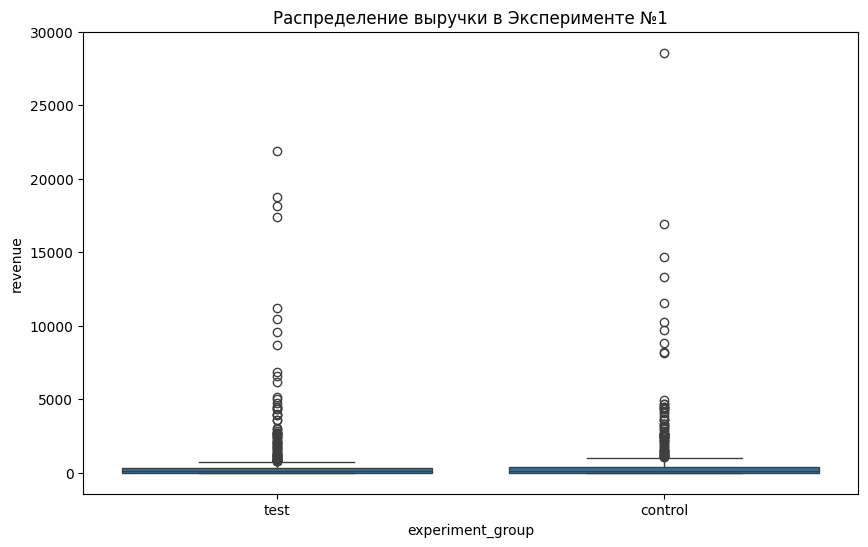

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='experiment_group', y='revenue', data=df[df['experiment_num'] == 1])
plt.title('Распределение выручки в Эксперименте №1')
plt.show()

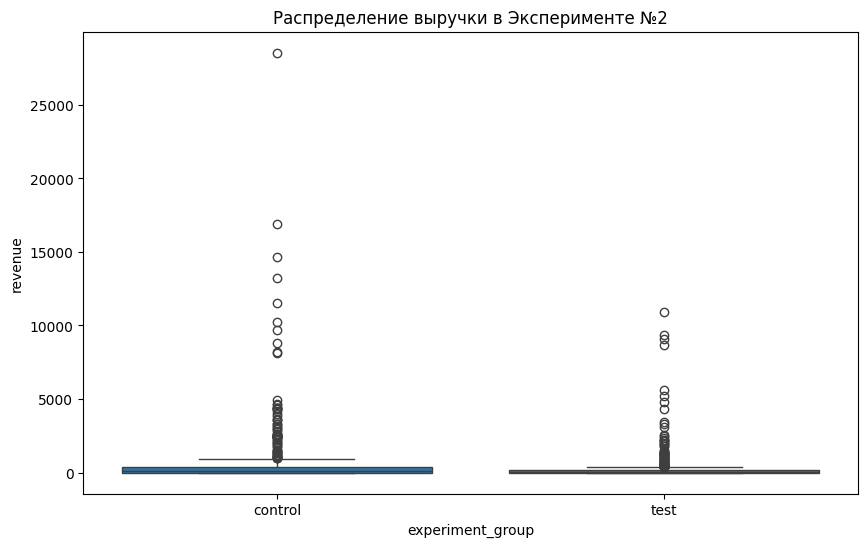

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='experiment_group', y='revenue', data=df[df['experiment_num'] == 2])
plt.title('Распределение выручки в Эксперименте №2')
plt.show()

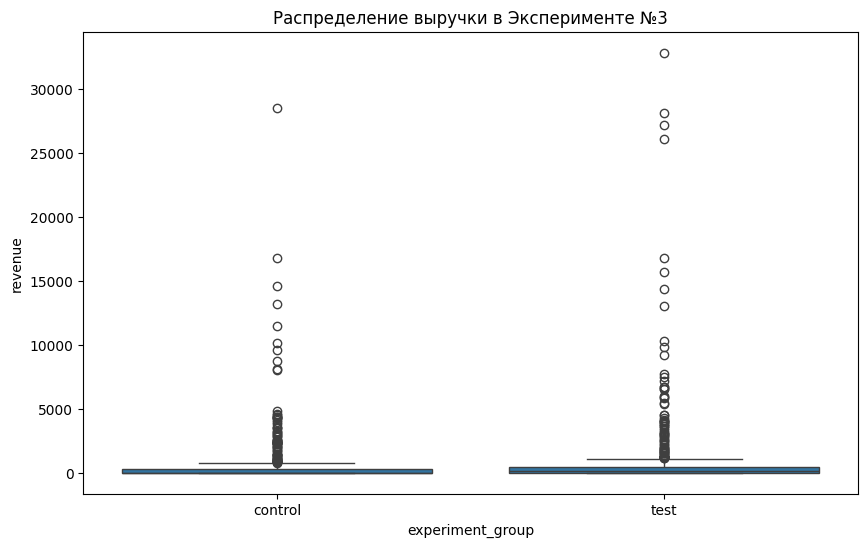

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='experiment_group', y='revenue', data=df[df['experiment_num'] == 3])
plt.title('Распределение выручки в Эксперименте №3')
plt.show()